In [1]:
import os #work with file paths
import json #read json config file
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random, numpy as np, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [2]:
#current file's directory
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()
#move up one level to project root
PROJECT_ROOT = os.path.dirname(BASE_DIR)
#config file path
config_path = os.path.join(PROJECT_ROOT, "config.local.json")
#initialize empty config
config = {}
#load config if file exists and is not empty
if os.path.exists(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        text = f.read().strip()
        if text:
            config = json.loads(text)
#paths from config
concrete_path = config.get("CONCRETE_DATA")
crack_forest_path = config.get("CRACK_FOREST")
maguire_path = config.get("MAGUIRE_DATA")
#check which paths are valid and store them in a dictionary
valid_paths = {}
for name, path in {
    "Concrete": concrete_path,
    "CrackForest": crack_forest_path,
    "Maguire": maguire_path,
}.items():
    if path and os.path.exists(path):
        valid_paths[name] = path

***CONCRETE CRACK - KAGGLE***

In [3]:
#Concrete Crack Images dataset

concrete_root = Path(valid_paths["Concrete"])
pos_dir = concrete_root / "Positive"
neg_dir = concrete_root / "Negative"

pos_files = list(pos_dir.glob("*"))
neg_files = list(neg_dir.glob("*"))

print("\nConcrete Dataset Summary")
print("Positive images:", len(pos_files))
print("Negative images:", len(neg_files))


Concrete Dataset Summary
Positive images: 20000
Negative images: 20000


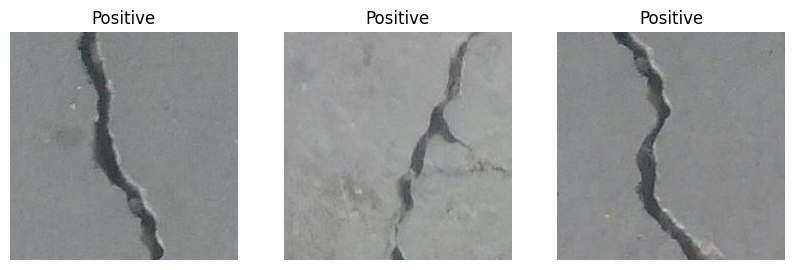

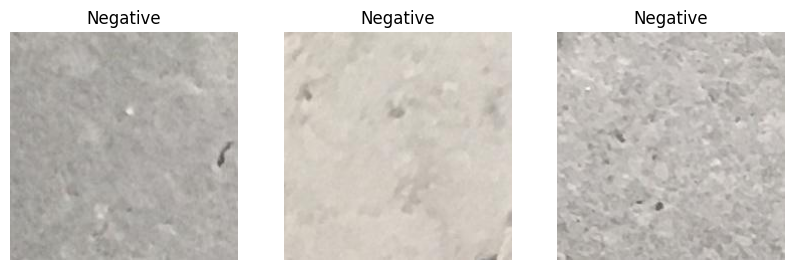

In [4]:
#show a few sample images from each class
pos_files_3example = list(pos_dir.glob("*"))[:3]
neg_files_3example = list(neg_dir.glob("*"))[:3]

def show_images(files, title):
    plt.figure(figsize=(10, 4))
    for i, file in enumerate(files):
        img = Image.open(file)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title)
    plt.show()

show_images(pos_files_3example, "Positive")
show_images(neg_files_3example, "Negative")

In [5]:
#combine positive files  as 1 and negative files as 0, then shuffle and split into train/val/test
data = [(p, 1) for p in pos_files] + [(n, 0) for n in neg_files]
random.shuffle(data)
n = len(data)
print(f"Total samples: {n}")
#80% train, 10% val, 10% test
train_end = int(0.8 * n)
val_end = int(0.9 * n)
train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

Total samples: 40000


In [6]:
#transforms for training and evaluation
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [7]:
#dataset class for loading images and labels
class CrackDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

In [8]:
#create datasets and dataloaders
train_ds = CrackDataset(train_data, transform=train_tfms)
val_ds   = CrackDataset(val_data,   transform=eval_tfms)
test_ds  = CrackDataset(test_data,  transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

In [ ]:
device = torch.device("cpu") 

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Using ResNet18")
print(model.fc)

Using ResNet18
Linear(in_features=512, out_features=1, bias=True)


In [10]:
def run_epoch(loader, train=False):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)  # (batch, 1)

            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y).sum().item()
            total += y.numel()   # safer than x.size(0)

    return total_loss / len(loader.dataset), correct / total


# -------------------
# TRAINING LOOP
# -------------------
epochs = 5
for epoch in range(epochs):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f}")

# -------------------
# TEST EVALUATION
# -------------------
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"\nTEST | loss {test_loss:.4f} acc {test_acc:.4f}")

Epoch 1/5 | Train loss 0.0135 acc 0.9960 | Val loss 0.0049 acc 0.9988
Epoch 2/5 | Train loss 0.0055 acc 0.9981 | Val loss 0.0022 acc 0.9990
Epoch 3/5 | Train loss 0.0054 acc 0.9985 | Val loss 0.0033 acc 0.9985
Epoch 4/5 | Train loss 0.0048 acc 0.9988 | Val loss 0.0018 acc 0.9992
Epoch 5/5 | Train loss 0.0037 acc 0.9988 | Val loss 0.0020 acc 0.9992

TEST | loss 0.0016 acc 0.9992


***
Crack Forest
***

In [ ]:
#imgs has all cracked concrete images, msks has all corresponding masks
#CrackForest dataset
images_dir = os.path.join(crack_forest_path, "Images")
masks_dir = os.path.join(crack_forest_path, "Masks")
#list and sort files in both directories
imgs = sorted(os.listdir(images_dir))
msks = sorted(os.listdir(masks_dir))

print("\nCrackForest:")
print("Images:", len(imgs))
print("Masks:", len(msks))

# check if filenames match
print("First image:", imgs[0] if imgs else "None")
print("First mask :", msks[0] if msks else "None")
#checking for missing pairs
missing = []
for img in imgs:
    expected_mask = img.replace(".jpg", "_label.PNG")
    if expected_mask not in msks:
        missing.append((img, expected_mask))
if missing:
    print("Missing pairs:", len(missing))
    print("Example:", missing[:5])
else:
    print("All images have corresponding masks.")


CrackForest:
Images: 118
Masks: 118
First image: 001.jpg
First mask : 001_label.PNG
All images have corresponding masks.


In [13]:

def clean_crackforest(root_dir):
    root_dir = Path(root_dir)
    images_dir = root_dir / "Images"
    masks_dir  = root_dir / "Masks"

    image_files = sorted([p for p in images_dir.glob("*.jpg")])
    mask_files  = sorted(list(masks_dir.glob("*")))
    mask_dict   = {m.name: m for m in mask_files}

    valid_pairs = []
    missing_masks = []
    unreadable = []
    size_mismatch = []

    for img_path in image_files:
        expected_mask_name = img_path.name.replace(".jpg", "_label.PNG")

        mask_path = mask_dict.get(expected_mask_name)
        if mask_path is None:
            missing_masks.append((img_path.name, expected_mask_name))
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")
        except Exception as e:
            unreadable.append((img_path.name, expected_mask_name, str(e)))
            continue

        if img.size != mask.size:
            size_mismatch.append((img_path.name, img.size, expected_mask_name, mask.size))

        valid_pairs.append((str(img_path), str(mask_path)))

    print("\n=== CrackForest Cleaning Report ===")
    print("Total images:", len(image_files))
    print("Valid pairs:", len(valid_pairs))
    print("Missing masks:", len(missing_masks))
    print("Unreadable files:", len(unreadable))
    print("Size mismatches:", len(size_mismatch))

    if missing_masks:
        print("Example missing:", missing_masks[:5])
    if size_mismatch:
        print("Example mismatch:", size_mismatch[:5])

    return valid_pairs

In [14]:
crackforest_root = valid_paths.get("CrackForest")

if crackforest_root:
    crackforest_pairs = clean_crackforest(crackforest_root)
else:
    print("CrackForest path not found.")


=== CrackForest Cleaning Report ===
Total images: 118
Valid pairs: 118
Missing masks: 0
Unreadable files: 0
Size mismatches: 0


***Maguire***

In [15]:
from pathlib import Path
from PIL import Image

def clean_maguire_classification(root_dir):
    root_dir = Path(root_dir)

    # Navigate to SDNET2018/P
    data_dir = root_dir / "SDNET2018" / "P"

    if not data_dir.exists():
        print("Expected path SDNET2018/P not found.")
        return []

    cp_dir = data_dir / "CP"  # cracked
    up_dir = data_dir / "UP"  # uncracked

    if not cp_dir.exists() or not up_dir.exists():
        print("CP or UP folders missing.")
        return []

    cp_files = list(cp_dir.glob("*"))
    up_files = list(up_dir.glob("*"))

    print("\n=== Maguire Dataset Summary ===")
    print("Cracked (CP):", len(cp_files))
    print("Uncracked (UP):", len(up_files))

    clean_data = []
    unreadable = []

    # Label: CP = 1, UP = 0
    for img_path in cp_files:
        try:
            with Image.open(img_path) as im:
                im.verify()
            clean_data.append((str(img_path), 1))
        except Exception as e:
            unreadable.append((str(img_path), str(e)))

    for img_path in up_files:
        try:
            with Image.open(img_path) as im:
                im.verify()
            clean_data.append((str(img_path), 0))
        except Exception as e:
            unreadable.append((str(img_path), str(e)))

    print("Total valid images:", len(clean_data))
    print("Unreadable images:", len(unreadable))

    return clean_data

In [16]:
maguire_root = valid_paths.get("Maguire")

if maguire_root:
    maguire_cleaned = clean_maguire_classification(maguire_root)
else:
    print("Maguire path not found.")


=== Maguire Dataset Summary ===
Cracked (CP): 2608
Uncracked (UP): 11010
Total valid images: 13618
Unreadable images: 0
